In [1]:
import os
import pickle
import matplotlib.pyplot as plt
import sys
import pandas as pd
internal_PDC_VS_MPC_dir = os.getcwd()
internal_may_8_dir = os.path.abspath(os.path.join(internal_PDC_VS_MPC_dir, '..'))
internal_MPC_data_dir = os.path.abspath(os.path.join(internal_may_8_dir, 'MPC'))
internal_PDC_data_dir = os.path.abspath(os.path.join(internal_may_8_dir, 'PDC'))
internal_VTR_dir = os.path.abspath(os.path.join(internal_PDC_VS_MPC_dir, '..', '..'))
root_dir = os.path.abspath(os.path.join(internal_VTR_dir, '..'))
internal_HT_dir = os.path.abspath(os.path.join(root_dir, '8_Hardware', 'Hardware_Testing'))
internal_HT_MPC_dir = os.path.abspath(os.path.join(internal_HT_dir, '2_MPC_Controllers'))
internal_scripts_dir = os.path.abspath(os.path.join(internal_HT_MPC_dir, 'scripts'))
sys.path.append(internal_scripts_dir)
import H_Common_Params as CP

In [2]:
internal_PDC_CDP_data_dir = os.path.abspath(os.path.join(internal_PDC_data_dir, 'Collected_Data_Python'))
internal_MPC_CDP_data_dir = os.path.abspath(os.path.join(internal_MPC_data_dir, 'Collected_Data_Python'))
print(f'The PDC data directory : {internal_PDC_CDP_data_dir}')
print(f'The MPC data directory : {internal_MPC_CDP_data_dir}')

The PDC data directory : d:\lord_of_darkness\IITM\5th_year\Adaptive-Cruise-Control\9_Vehicle_Testing_Results\May_08\PDC\Collected_Data_Python
The MPC data directory : d:\lord_of_darkness\IITM\5th_year\Adaptive-Cruise-Control\9_Vehicle_Testing_Results\May_08\MPC\Collected_Data_Python


In [3]:
PDC_data_list = []
for i in range(len(os.listdir(internal_PDC_CDP_data_dir))):
    PDC_data_list.append(pd.read_csv(os.path.join(internal_PDC_CDP_data_dir, os.listdir(internal_PDC_CDP_data_dir)[i])))
    
MPC_data_list = []
for i in range(len(os.listdir(internal_MPC_CDP_data_dir))):
    MPC_data_list.append(pd.read_csv(os.path.join(internal_MPC_CDP_data_dir, os.listdir(internal_MPC_CDP_data_dir)[i])))

In [4]:
plot_PDC_data_list = [PDC_data_list[1], PDC_data_list[3]]
plot_MPC_data_list = [MPC_data_list[0], MPC_data_list[1]]

In [5]:
def plot(ego_positions, ego_velocities, obs_positions, obs_velocities, times, detection_separation, title):
    fig, axes = plt.subplots(1, 2, figsize = (60, 25 * 1))                              # figsize = (width, height)
    font = 50
    border_thickness = 8.0
    
    for i in range(2):
        for spine in axes[i].spines.values():
            spine.set_linewidth(border_thickness)  # Set border (spine) thickness
    
    plot_separations_PDC = [obs_positions[0][i] - ego_positions[0][i] for i in range(len(obs_positions[0]))]
    plot_separations_MPC = [obs_positions[1][i] - ego_positions[1][i] for i in range(len(obs_positions[1]))]
    plot_velocities_PDC = [ego_velocities[0][i] * 18 / 5 for i in range(len(ego_velocities[0]))]
    plot_velocities_MPC = [ego_velocities[1][i] * 18 / 5 for i in range(len(ego_velocities[1]))]
    index_PDC = next((i for i, x in enumerate(plot_separations_PDC[1:]) if x < detection_separation), -1)
    index_MPC = next((i for i, x in enumerate(plot_separations_MPC[1:]) if x < detection_separation), -1)

    axes[0].plot(times[0], plot_separations_PDC, label = f'PD', color = 'purple', linewidth = 4)
    axes[0].plot(times[1], plot_separations_MPC, label = f'MPC', color = 'blue', linewidth = 4)
    axes[0].axvline(x = times[0][index_PDC], color = 'black', linestyle = '--', label = 'Obstacle detected_PD', linewidth = 4)
    axes[0].axvline(x = times[1][index_MPC], color = 'red', linestyle = '--', label = 'Obstacle detected_MPC', linewidth = 4)
    axes[0].plot(times[0][index_PDC:], [CP.Dd + CP.Td * Vego for Vego in ego_velocities[0][index_PDC:]], label = f'Desired final seperation_PD', color = 'green', linewidth = 6)
    axes[0].plot(times[1][index_MPC:], [CP.Dd + CP.Td * Vego for Vego in ego_velocities[1][index_MPC:]], label = f'Desired final seperation_MPC', color = 'yellow', linewidth = 6)    
    axes[0].grid(True, linewidth = 4.0)
    axes[0].set_xlabel('Time [s]', fontsize = font, fontweight = 'bold')
    axes[0].set_ylabel('Separation [m]', fontsize = font, fontweight = 'bold')
    axes[0].set_title(title, fontsize = font, fontweight = 'bold')
    axes[0].tick_params(axis = 'both', which = 'major', labelsize = font, width = 2)
    axes[0].legend(fontsize = font)

    axes[1].plot(times[0], plot_velocities_PDC, label = f'PD', color = 'purple', linewidth = 4)
    axes[1].plot(times[1], plot_velocities_MPC, label = f'MPC', color = 'blue', linewidth = 4)
    axes[1].axvline(x = times[0][index_PDC], color = 'black', linestyle = '--', label = 'Obstacle detected_PD', linewidth = 4)
    axes[1].axvline(x = times[1][index_MPC], color = 'red', linestyle = '--', label = 'Obstacle detected_MPC', linewidth = 4)
    axes[1].plot(times[0][index_PDC:], [Vobs * 18 / 5 for Vobs in obs_velocities[0][index_PDC:]], label = f'Desired velocity_PD', color = 'green', linewidth = 6)
    axes[1].plot(times[1][index_MPC:], [Vobs * 18 / 5 for Vobs in obs_velocities[1][index_MPC:]], label = f'Desired velocity_MPC', color = 'yellow', linewidth = 6)
    axes[1].grid(True, linewidth = 4.0)
    axes[1].set_xlabel('Time [s]', fontsize = font, fontweight = 'bold')
    axes[1].set_ylabel('Velocity [km/hr]', fontsize = font, fontweight = 'bold')
    axes[1].set_title(title, fontsize = font, fontweight = 'bold')
    axes[1].tick_params(axis = 'both', which = 'major', labelsize = font, width = 2)
    axes[1].legend(fontsize = font)

    plt.show()

In [6]:
titles = ['Cut in scenario (Scenario 1)', 'Complete stopping scenario (Scenario 3)']
detection_seperations = [20.0, 90.0]

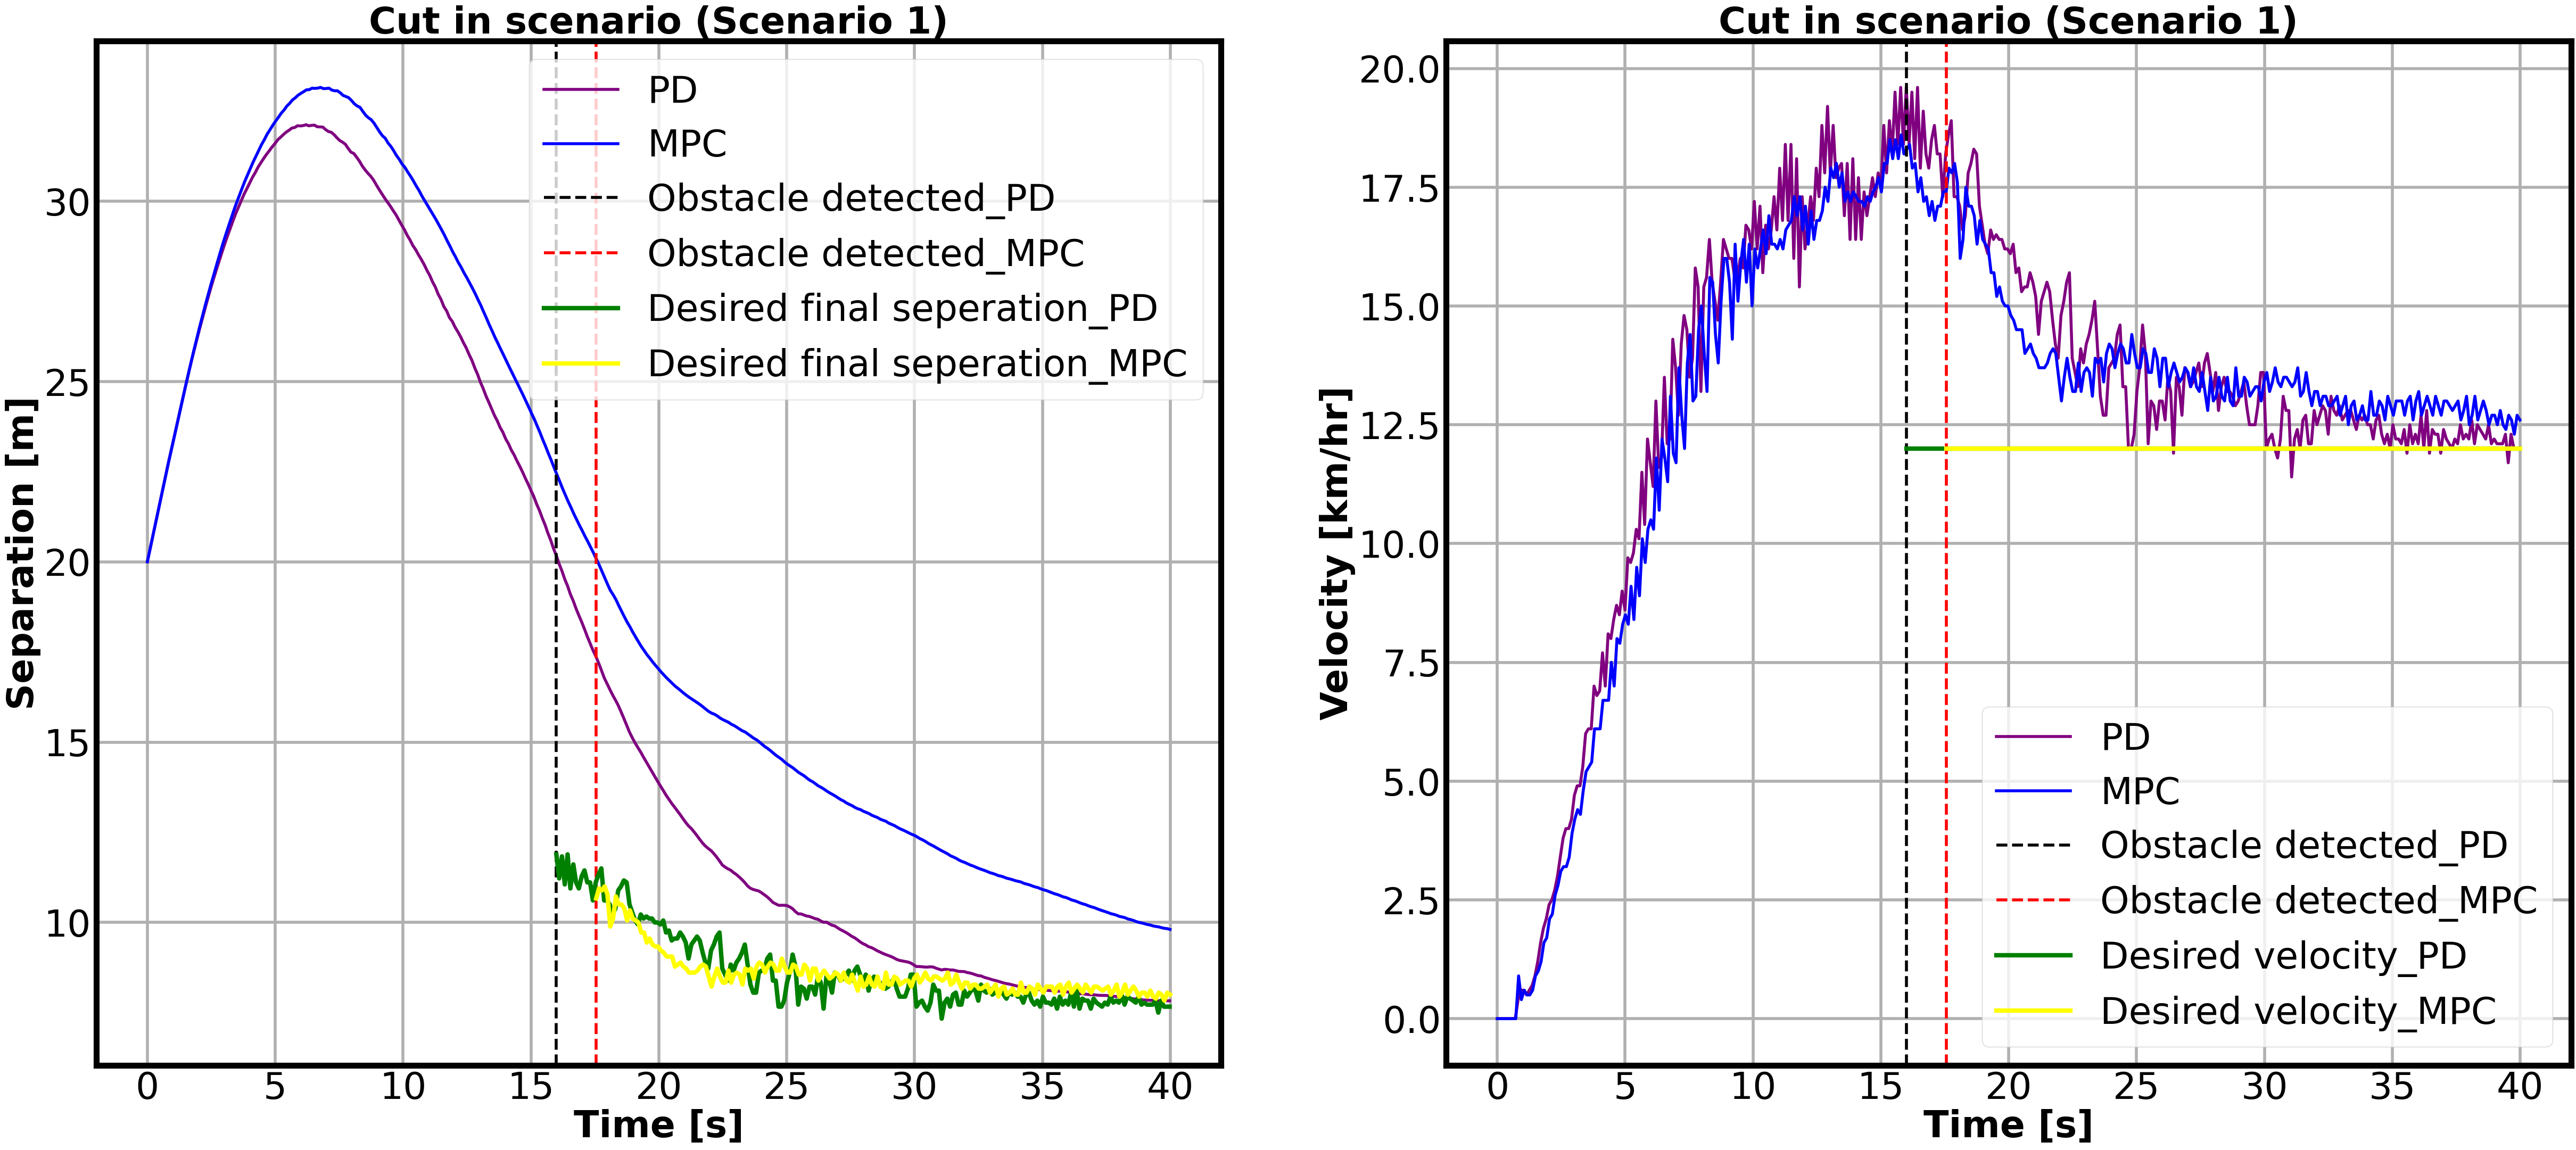

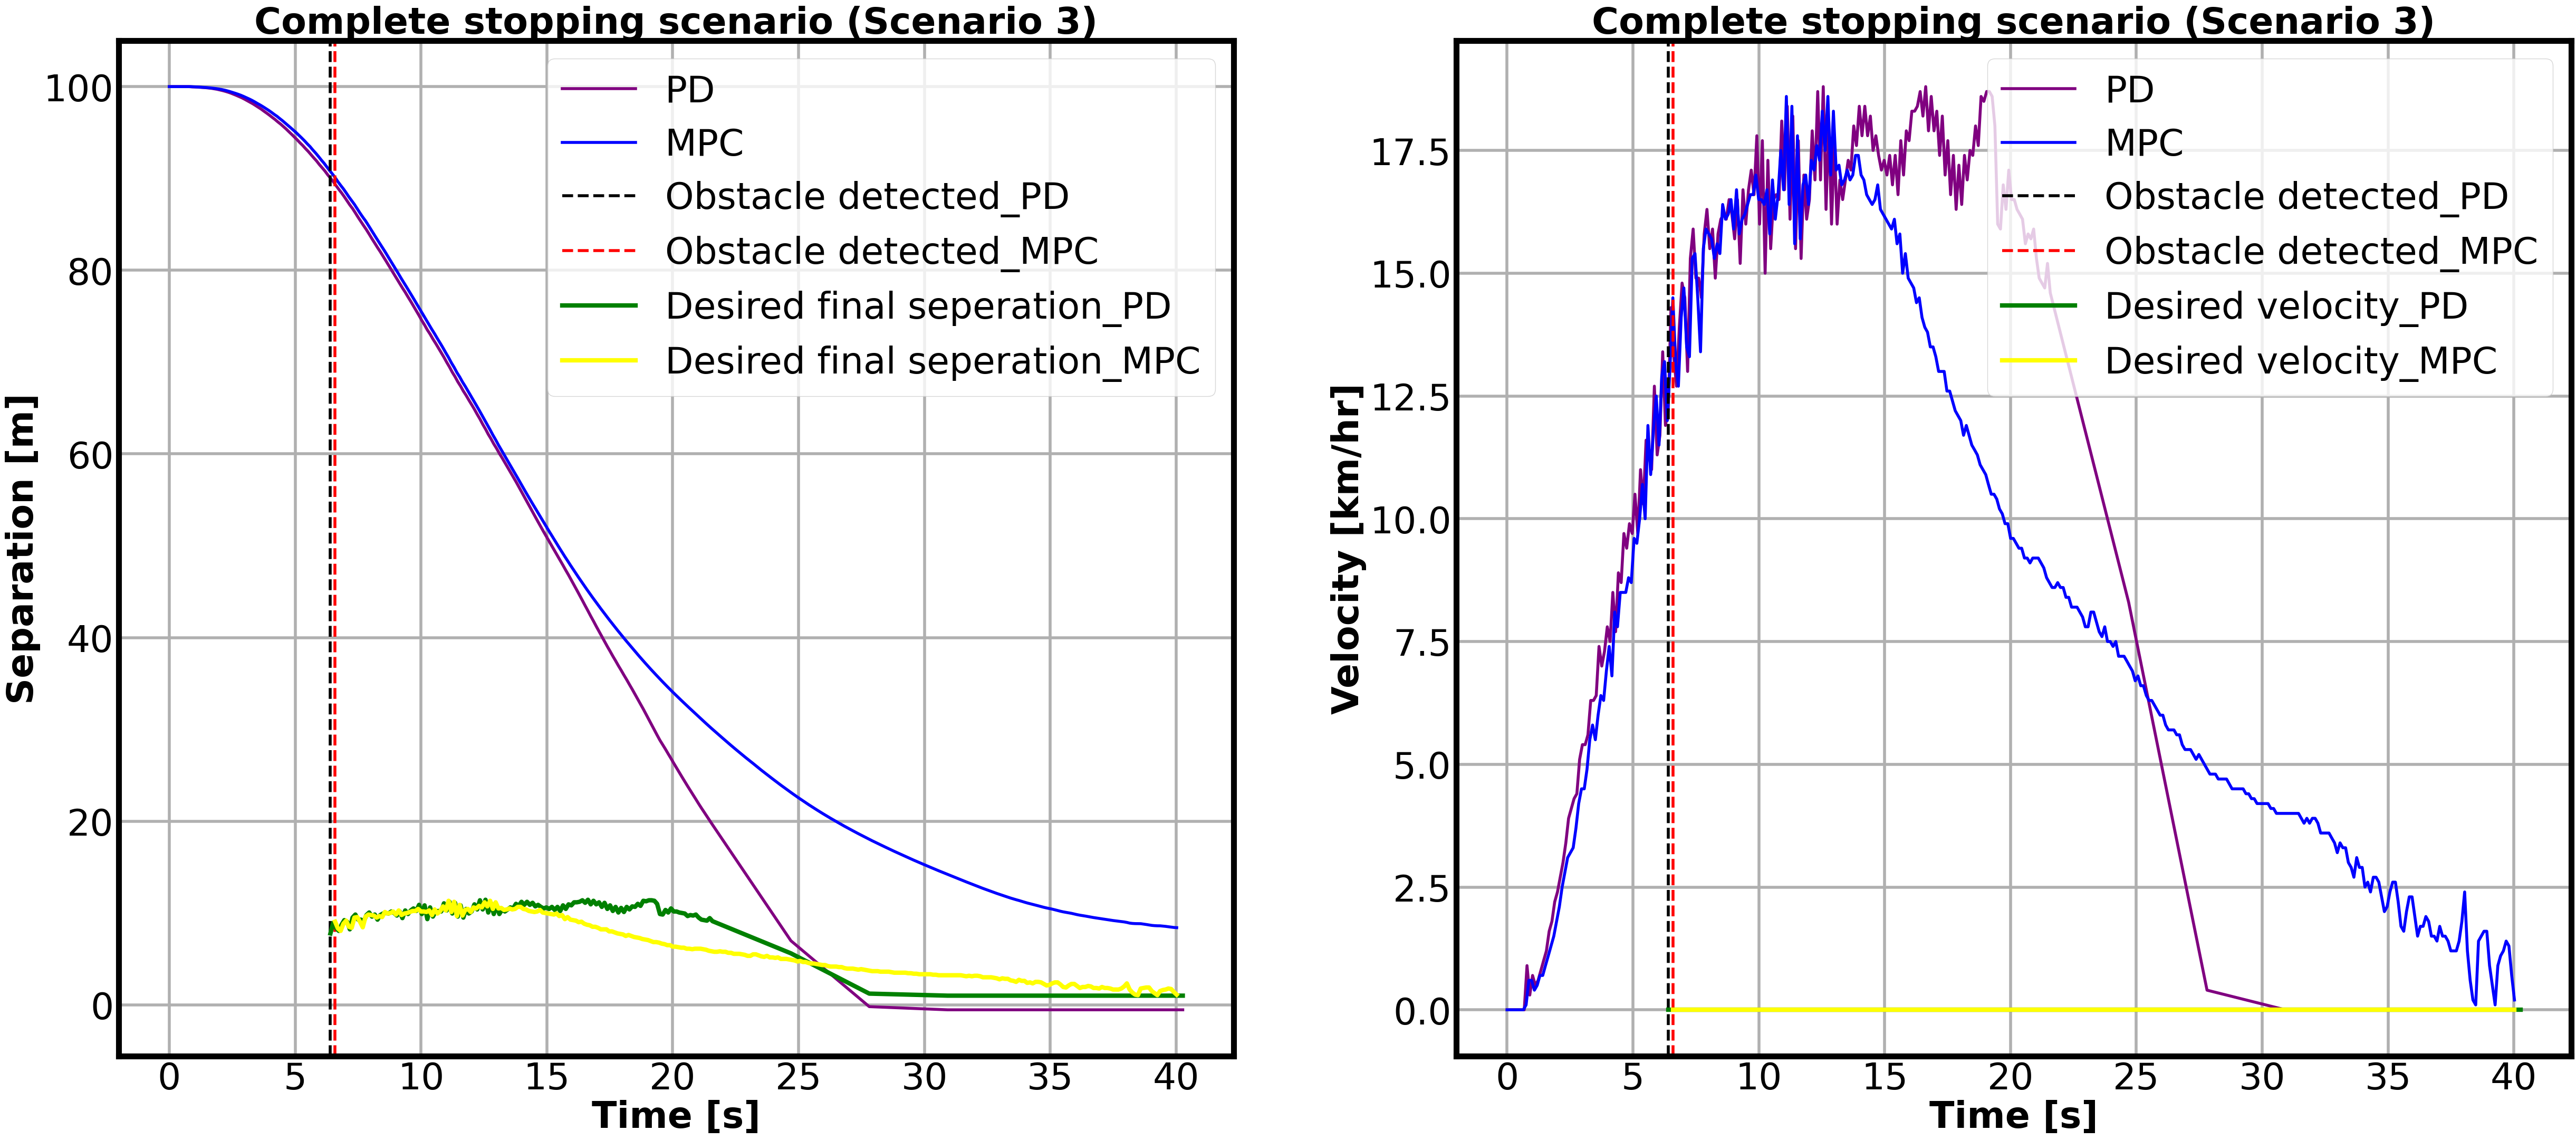

In [7]:
for i in range(len(plot_PDC_data_list)):
    plot([list(plot_PDC_data_list[i]['Ego_Position(m)']), list(plot_MPC_data_list[i]['Ego_Position(m)'])], [list(plot_PDC_data_list[i]['Ego_Velocity(m/s)']), list(plot_MPC_data_list[i]['Ego_Velocity(m/s)'])], [list(plot_PDC_data_list[i]['Obs_Position(m)']), list(plot_MPC_data_list[i]['Obs_Position(m)'])], [list(plot_PDC_data_list[i]['Obs_Velocity(m/s)']), list(plot_MPC_data_list[i]['Obs_Velocity(m/s)'])], [list(plot_PDC_data_list[i]['Time(s)']), list(plot_MPC_data_list[i]['Time(s)'])], detection_seperations[i], titles[i])